### How does angle of attack affect lift/downforce and drag?

In [19]:
import aerosandbox as asb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

airfoil = asb.Airfoil("naca4412")

alphas = np.linspace(-10, 15, 26)

results = []


for alpha in alphas:
    aero = airfoil.get_aero_from_neuralfoil(
        alpha = alpha,
        Re = 500000,
        mach = 0.05
    )

    CL = aero["CL"][0]
    CD = aero["CD"][0]

    results.append({
        "alpha_deg": alpha,
        "CL": CL,
        "CD": CD,
        "CL_CD": CL/CD
    })

df = pd.DataFrame(results)
df.head()

,alpha_deg,CL,CD,CL_CD
0,-10.0,-0.672868,0.022094,-30.454331
1,-9.0,-0.548183,0.018506,-29.621416
2,-8.0,-0.420325,0.015718,-26.741335
3,-7.0,-0.294891,0.013536,-21.786017
4,-6.0,-0.174770,0.011850,-14.748228


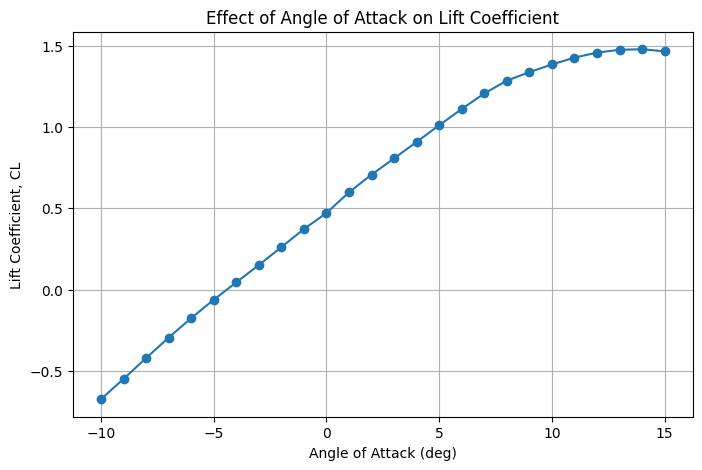

In [2]:
## CL vs angle of attack
plt.figure(figsize=(8, 5))
plt.plot(df["alpha_deg"], df["CL"], marker="o")
plt.xlabel("Angle of Attack (deg)")
plt.ylabel("Lift Coefficient, CL")
plt.title("Effect of Angle of Attack on Lift Coefficient")
plt.grid(True)
plt.show()

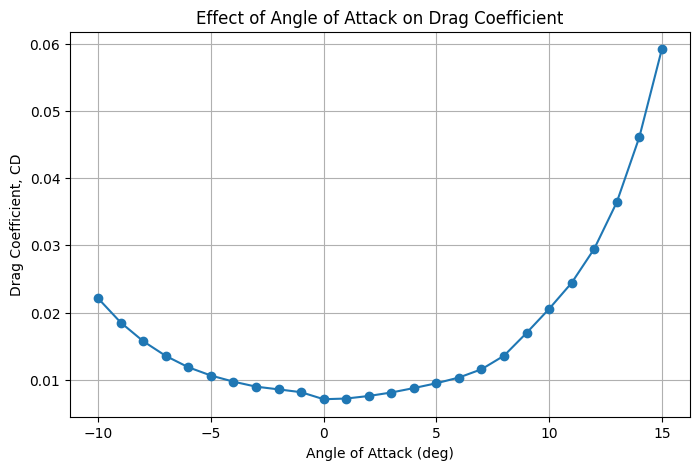

In [3]:
## CD vs angle of attack
plt.figure(figsize=(8, 5))
plt.plot(df["alpha_deg"], df["CD"], marker="o")
plt.xlabel("Angle of Attack (deg)")
plt.ylabel("Drag Coefficient, CD")
plt.title("Effect of Angle of Attack on Drag Coefficient")
plt.grid(True)
plt.show()

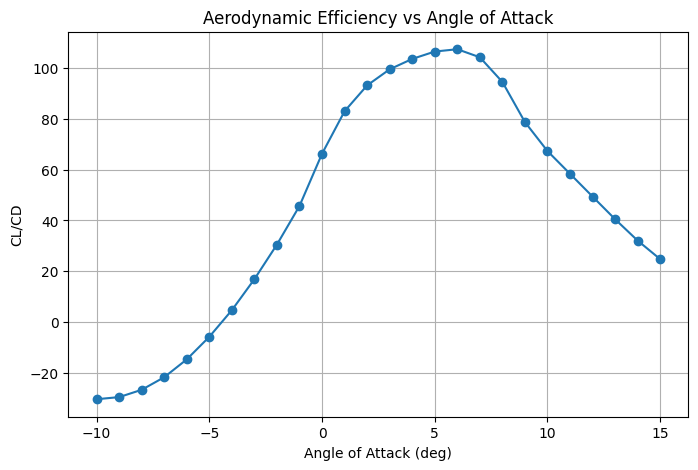

In [4]:
## CL/CD vs angle of attack
plt.figure(figsize=(8, 5))
plt.plot(df["alpha_deg"], df["CL_CD"], marker="o")
plt.xlabel("Angle of Attack (deg)")
plt.ylabel("CL/CD")
plt.title("Aerodynamic Efficiency vs Angle of Attack")
plt.grid(True)
plt.show()

### Comparing different airfoils

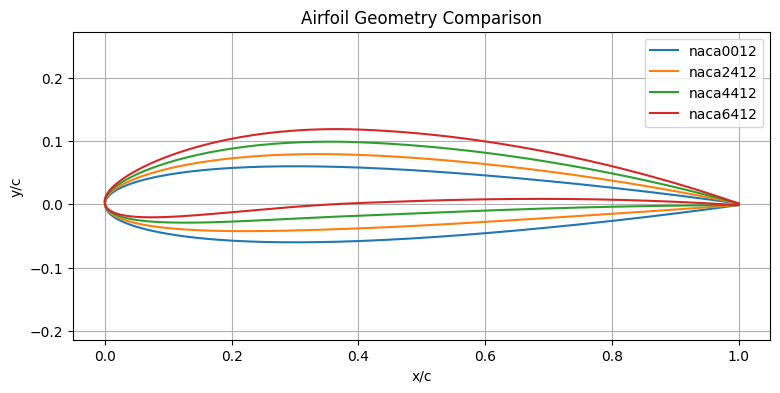

In [ ]:
## Shape of the four airfoils

plt.figure(figsize=(9, 4))

airfoils = ["naca0012", "naca2412", "naca4412", "naca6412"]

for af_name in airfoils:
    airfoil = asb.Airfoil(af_name)
    coords = airfoil.coordinates
    
    plt.plot(
        coords[:, 0],
        coords[:, 1],
        label=af_name
    )

plt.xlabel("x/c")
plt.ylabel("y/c")
plt.title("Airfoil Geometry Comparison")
plt.axis("equal")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
airfoils = ["naca0012", "naca2412", "naca4412", "naca6412"]
alphas = np.linspace(-10, 15, 26)

all_results = []

for af_name in airfoils:
    airfoil = asb.Airfoil(af_name)

    for alpha in alphas:
        aero = airfoil.get_aero_from_neuralfoil(
            alpha = alpha,
            Re = 500000,
            mach = 0.05
        )
        CL = aero["CL"][0]
        CD = aero["CD"][0]

        all_results.append({
            "airfoil": af_name,
            "alpha_deg": alpha,
            "CL": CL,
            "CD": CD,
            "CL_CD": CL/CD,
            "downforce_coeff": -CL
        })

df_all = pd.DataFrame(all_results)
df_all.head()

,airfoil,alpha_deg,CL,CD,CL_CD,downforce_coeff
0,naca0012,-10.0,-1.041923,0.018979,-54.898445,1.041923
1,naca0012,-9.0,-0.964299,0.016667,-57.858237,0.964299
2,naca0012,-8.0,-0.884086,0.014822,-59.648071,0.884086
3,naca0012,-7.0,-0.799435,0.013307,-60.076267,0.799435
4,naca0012,-6.0,-0.704639,0.011867,-59.378557,0.704639


In [23]:
## for best downforce

best_downforce = df_all.sort_values("downforce_coeff", ascending=False).head(10)
best_downforce

,airfoil,alpha_deg,CL,CD,CL_CD,downforce_coeff,downforce_drag_ratio
0,naca0012,-10.0,-1.041923,0.018979,-54.898445,1.041923,54.898445
1,naca0012,-9.0,-0.964299,0.016667,-57.858237,0.964299,57.858237
26,naca2412,-10.0,-0.887037,0.019986,-44.383463,0.887037,44.383463
2,naca0012,-8.0,-0.884086,0.014822,-59.648071,0.884086,59.648071
27,naca2412,-9.0,-0.805647,0.017678,-45.573334,0.805647,45.573334
3,naca0012,-7.0,-0.799435,0.013307,-60.076267,0.799435,60.076267
4,naca0012,-6.0,-0.704639,0.011867,-59.378557,0.704639,59.378557
28,naca2412,-8.0,-0.698443,0.015668,-44.578838,0.698443,44.578838
52,naca4412,-10.0,-0.672868,0.022094,-30.454331,0.672868,30.454331
5,naca0012,-5.0,-0.594806,0.010337,-57.539727,0.594806,57.539727


NACA0012 at -10 deg gives the greatest downforce. However, we don't only choose the airfoil that gives the maximum downforce.

In [ ]:
## for best efficiency (gives most downforce for least drag penalty)

df_all["downforce_drag_ratio"] = df_all["downforce_coeff"] / df_all["CD"]

best_efficiency = df_all.sort_values("downforce_drag_ratio", ascending=False).head(10)
best_efficiency

,airfoil,alpha_deg,CL,CD,CL_CD,downforce_coeff,downforce_drag_ratio
3,naca0012,-7.0,-0.799435,0.013307,-60.076267,0.799435,60.076267
2,naca0012,-8.0,-0.884086,0.014822,-59.648071,0.884086,59.648071
4,naca0012,-6.0,-0.704639,0.011867,-59.378557,0.704639,59.378557
1,naca0012,-9.0,-0.964299,0.016667,-57.858237,0.964299,57.858237
5,naca0012,-5.0,-0.594806,0.010337,-57.539727,0.594806,57.539727
0,naca0012,-10.0,-1.041923,0.018979,-54.898445,1.041923,54.898445
6,naca0012,-4.0,-0.468191,0.009056,-51.699242,0.468191,51.699242
27,naca2412,-9.0,-0.805647,0.017678,-45.573334,0.805647,45.573334
28,naca2412,-8.0,-0.698443,0.015668,-44.578838,0.698443,44.578838
26,naca2412,-10.0,-0.887037,0.019986,-44.383463,0.887037,44.383463


Taking into account drag penalty, the airfoil that gives the best efficiency is NACA0012 at -7 deg.

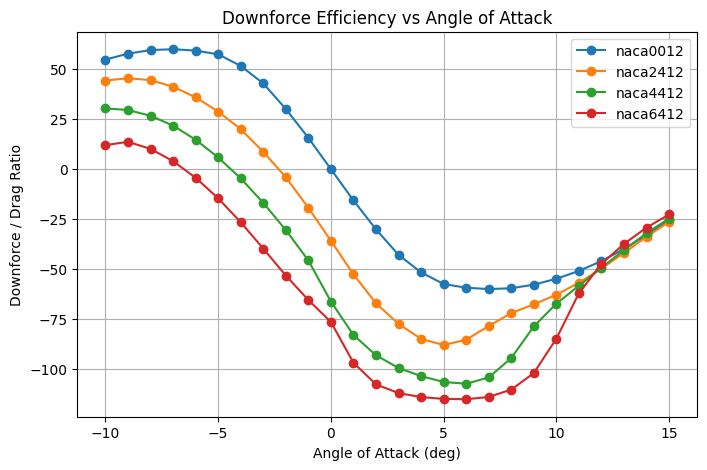

In [25]:
plt.figure(figsize=(8, 5))

for af_name in df_all["airfoil"].unique():
    subset = df_all[df_all["airfoil"] == af_name]
    plt.plot(
        subset["alpha_deg"],
        subset["downforce_drag_ratio"],
        marker="o",
        label=af_name
    )

plt.xlabel("Angle of Attack (deg)")
plt.ylabel("Downforce / Drag Ratio")
plt.title("Downforce Efficiency vs Angle of Attack")
plt.legend()
plt.grid(True)
plt.show()

The higher the downforce/drag ratio, the greater the downforce generation and lower drag. This implies greater aerodynamic efficiency. While lower, negative values signifies that there is too much drag for the downforce produced, and might potentially have unfavourable flow behaviour.

Overall, NACA0012 performs the best, where the CL/CD ratio is around 60 when angle of attack is around -7 deg. This suggests that the symmetric airdoil performs most efficiently under negative angles of attack. 

This is also observed in an F1-styled wing, where inverted wings often have symmetric/specially-shaped profiles. This is likely due to the need for predictable flow behaviour and how F1 cars operate under aggressive pressure gradients.

As angle increases, all curves trend downward. This means that drag increases rapidly, downforce becomes less favourable and aerodynamic efficienct worsens. At high positive angles, flow separation may begin and drag dominates.

The more cambered airfoils (NACA4412 and NACA6412) have poorer efficienct under negative angles. These airfoils are designed primarily for positive lift generation, like aircraft wings, and when negatively loaded, the geometry becomes less favourable where pressure distribution worsens and drag increases faster.

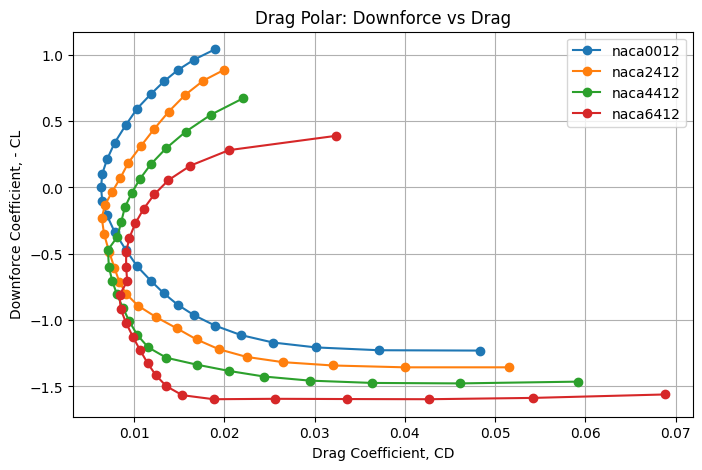

In [ ]:
## Drag Polar: Downforce VS Drag

plt.figure(figsize=(8, 5))

for af_name in df_all["airfoil"].unique():
    subset = df_all[df_all["airfoil"] == af_name]
    plt.plot(
        subset["CD"],
        subset["downforce_coeff"],
        marker="o",
        label=af_name
    )

plt.xlabel("Drag Coefficient, CD")
plt.ylabel("Downforce Coefficient, - CL")
plt.title("Drag Polar: Downforce vs Drag")
plt.legend()
plt.grid(True)
plt.show()

The drag polar demonstrated that increasing downforce came with a significant drag penalty. As angle of attack changes (the different points), downforce increases but drag also increases. Initially, downforce rises efficiently, but drag also rises rapidly and efficiency worsens. This is why the curve bends.

Among the airfoils studied, the NACA0012 profile achieved a more favourable balance between downforce generation and drag accumulation under negative angles of attack, suggesting better suitability for inverted wing applications such as motorsport aerodynamic devices. 

In [31]:
## Optimisation summary table for all airfoils

summary = []

for af_name in df_all["airfoil"].unique():
    subset = df_all[df_all["airfoil"] == af_name]
    
    max_downforce = subset.loc[subset["downforce_coeff"].idxmax()]
    best_efficiency = subset.loc[subset["downforce_drag_ratio"].idxmax()]
    min_drag = subset.loc[subset["CD"].idxmin()]
    
    summary.append({
        "airfoil": af_name,
        "max_downforce_alpha": max_downforce["alpha_deg"],
        "max_downforce_coeff": max_downforce["downforce_coeff"],
        "best_efficiency_alpha": best_efficiency["alpha_deg"],
        "best_downforce_drag_ratio": best_efficiency["downforce_drag_ratio"],
        "min_drag_alpha": min_drag["alpha_deg"],
        "min_CD": min_drag["CD"]
    })

summary_df = pd.DataFrame(summary)
summary_df

,airfoil,max_downforce_alpha,max_downforce_coeff,best_efficiency_alpha,best_downforce_drag_ratio,min_drag_alpha,min_CD
0,naca0012,-10.0,1.041923,-7.0,60.076267,0.0,0.006337
1,naca2412,-10.0,0.887037,-9.0,45.573334,0.0,0.006415
2,naca4412,-10.0,0.672868,-10.0,30.454331,0.0,0.007098
3,naca6412,-10.0,0.388610,-9.0,13.710181,1.0,0.008379
